Using Colab cache for faster access to the 'bladder-cancer-global-globocan-2022' dataset.
 Data Loaded Successfully

                         Treatment Treatment_Type  \
0  TURBT (Transurethral Resection)        Surgery   
1         Intravesical BCG Therapy  Immunotherapy   
2        Intravesical Chemotherapy   Chemotherapy   
3               Radical Cystectomy        Surgery   
4         Neoadjuvant Chemotherapy   Chemotherapy   

                    Indication   Stage_Applicability  Response_Rate_Pct  \
0  Non-muscle-invasive (NMIBC)           Ta, T1, CIS               85.0   
1              High-risk NMIBC  CIS, high-risk Ta/T1               70.0   
2  Low/intermediate-risk NMIBC       Ta, low-risk T1               75.0   
3       Muscle-invasive (MIBC)                T2-T4a               70.0   
4           MIBC (pre-surgery)                T2-T4a               65.0   

   Five_Year_OS_Pct                                Common_Side_Effects  \
0              75.0  Bladder perforatio

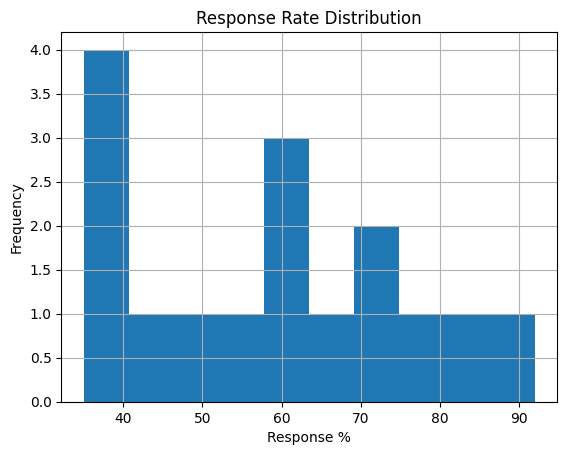

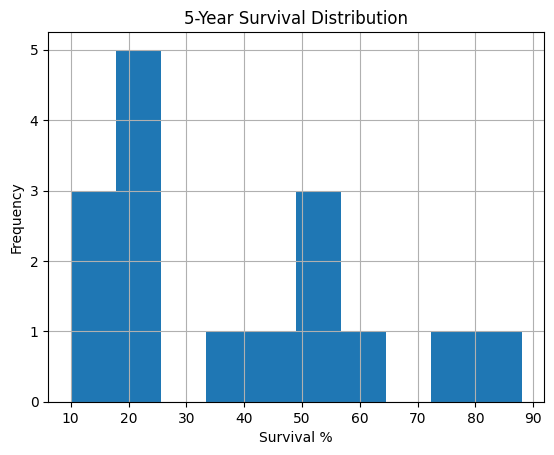

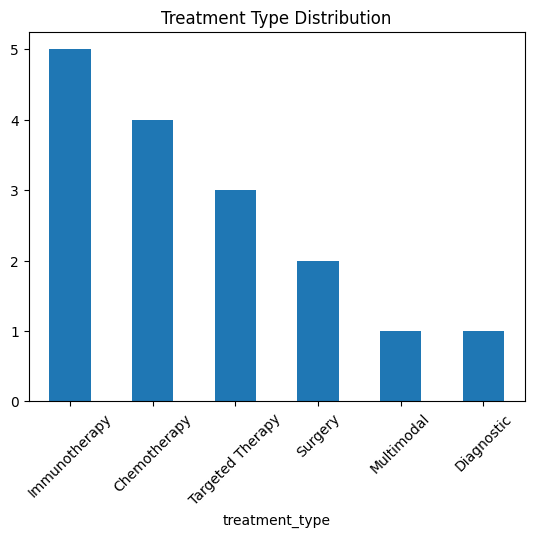

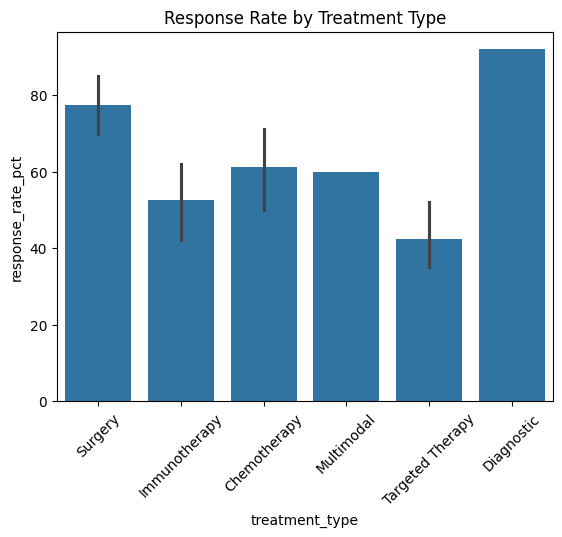

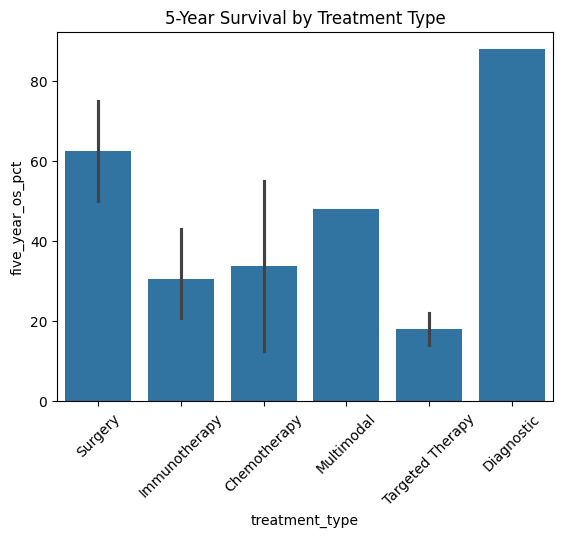

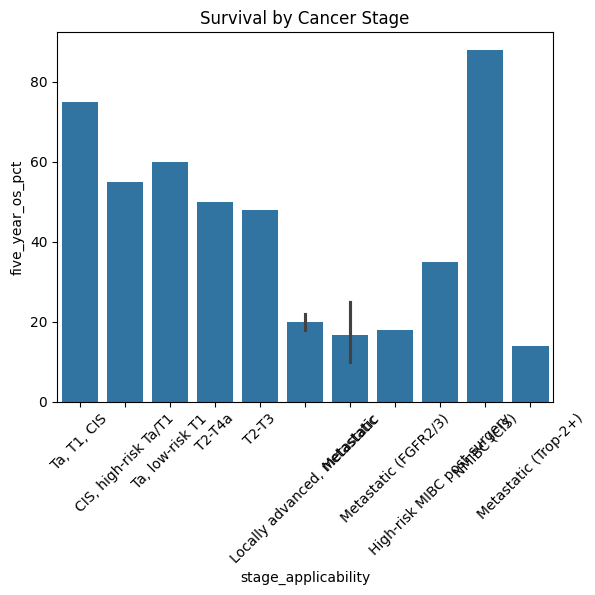

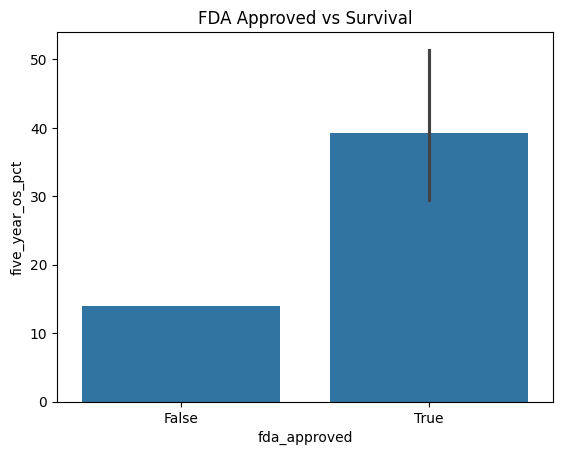

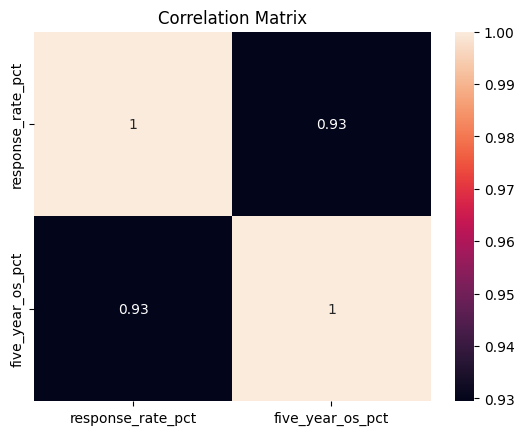


 SQL Table Created

 Response by Treatment Type:
     treatment_type  avg_response
0      Chemotherapy     61.250000
1        Diagnostic     92.000000
2     Immunotherapy     52.600000
3        Multimodal     60.000000
4           Surgery     77.500000
5  Targeted Therapy     42.333333

 Survival by Treatment Type:
     treatment_type  avg_survival
0      Chemotherapy         33.75
1        Diagnostic         88.00
2     Immunotherapy         30.60
3        Multimodal         48.00
4           Surgery         62.50
5  Targeted Therapy         18.00

 Survival by Stage:
             stage_applicability  avg_survival
0           CIS, high-risk Ta/T1     55.000000
1    High-risk MIBC post-surgery     35.000000
2   Locally advanced, metastatic     20.000000
3                     Metastatic     16.666667
4           Metastatic (FGFR2/3)     18.000000
5           Metastatic (Trop-2+)     14.000000
6                    NMIBC (CIS)     88.000000
7                          T2-T3     48.000000


In [20]:

import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


path = kagglehub.dataset_download("zkskhurram/bladder-cancer-global-globocan-2022")

file_path = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        file_path = os.path.join(path, file)

if file_path is None:
    raise Exception("No CSV file found")

df = pd.read_csv(file_path)

print(" Data Loaded Successfully\n")
print(df.head())


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w_]", "", regex=True)
)

df.drop_duplicates(inplace=True)

print("\n Cleaned Columns:")
print(df.columns.tolist())


print("\n Dataset Info:")
print(df.info())

print("\n Summary Statistics:")
print(df.describe())


response_col = 'response_rate_pct'
survival_col = 'five_year_os_pct'
treatment_col = 'treatment_type'
stage_col = 'stage_applicability'
fda_col = 'fda_approved'


print("\n Key Metrics:")

print("Average Response Rate:", df[response_col].mean())
print("Average 5-Year Survival:", df[survival_col].mean())


plt.figure()
df[response_col].hist()
plt.title("Response Rate Distribution")
plt.xlabel("Response %")
plt.ylabel("Frequency")
plt.show()


plt.figure()
df[survival_col].hist()
plt.title("5-Year Survival Distribution")
plt.xlabel("Survival %")
plt.ylabel("Frequency")
plt.show()


plt.figure()
df[treatment_col].value_counts().plot(kind='bar')
plt.title("Treatment Type Distribution")
plt.xticks(rotation=45)
plt.show()


plt.figure()
sns.barplot(x=treatment_col, y=response_col, data=df)
plt.title("Response Rate by Treatment Type")
plt.xticks(rotation=45)
plt.show()


plt.figure()
sns.barplot(x=treatment_col, y=survival_col, data=df)
plt.title("5-Year Survival by Treatment Type")
plt.xticks(rotation=45)
plt.show()


plt.figure()
sns.barplot(x=stage_col, y=survival_col, data=df)
plt.title("Survival by Cancer Stage")
plt.xticks(rotation=45)
plt.show()


plt.figure()
sns.barplot(x=fda_col, y=survival_col, data=df)
plt.title("FDA Approved vs Survival")
plt.show()


plt.figure()
corr = df[[response_col, survival_col]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()


conn = sqlite3.connect("cancer.db")
df.to_sql("cancer_data", conn, if_exists='replace', index=False)

print("\n SQL Table Created")


query1 = """
SELECT treatment_type, AVG(response_rate_pct) as avg_response
FROM cancer_data
GROUP BY treatment_type
"""
print("\n Response by Treatment Type:")
print(pd.read_sql(query1, conn))


query2 = """
SELECT treatment_type, AVG(five_year_os_pct) as avg_survival
FROM cancer_data
GROUP BY treatment_type
"""
print("\n Survival by Treatment Type:")
print(pd.read_sql(query2, conn))


query3 = """
SELECT stage_applicability, AVG(five_year_os_pct) as avg_survival
FROM cancer_data
GROUP BY stage_applicability
"""
print("\n Survival by Stage:")
print(pd.read_sql(query3, conn))


query4 = """
SELECT fda_approved, AVG(five_year_os_pct) as avg_survival
FROM cancer_data
GROUP BY fda_approved
"""
print("\n FDA Approved vs Survival:")
print(pd.read_sql(query4, conn))

print("\n ANALYSIS COMPLETED SUCCESSFULLY")